In [ ]:
!pip install fredapi hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.5 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from datetime import datetime
import warnings

In [ ]:

# Set plot style for aesthetics
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings('ignore')

###Phase 1: Data Acquisition

In [ ]:
FRED_API_KEY = '04ba8ad63a3a886cc6d4e37c78c4c0af' # plz use your own API

TICKERS = {
        # Equities & Volatility
        'SPX': '^GSPC',      # S&P 500 Index
        'VIX': '^VIX',       # CBOE Volatility Index
        # Commodities
        'GOLD': 'GC=F',      # Gold Futures
        'OIL': 'CL=F',       # Crude Oil Futures
        # Currencies
        'SHY': 'SHY',       #1–3 Year Treasury Bond ETF
        'USD': 'DX-Y.NYB',   # US Dollar Index
        # Bonds (FRED)
        'T10Y2Y': 'T10Y2Y',  # 10-Year vs 2-Year Treasury Yield Spread
        'HYG_SPREAD': 'BAMLH0A0HYM2' # ICE BofA US High Yield Index Option-Adjusted Spread
    }

START_DATE = '2005-01-01'
END_DATE = '2025-11-12'

In [ ]:
def fetch_data(tickers, start_date, end_date, fred_api_key):

    # Separate tickers by source
    yf_tickers = {k: v for k, v in tickers.items() if k not in ['T10Y2Y', 'HYG_SPREAD']}
    fred_tickers = {k: v for k, v in tickers.items() if k in ['T10Y2Y', 'HYG_SPREAD']}

    # Fetch data from Yahoo Finance
    yf_data_list = []
    for key, ticker in yf_tickers.items():
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
        data.name = key
        yf_data_list.append(data)
    market_data = pd.concat(yf_data_list, axis=1)

    # Fetch data from FRED
    fred = Fred(api_key=fred_api_key)
    fred_data_list = []
    for key, ticker in fred_tickers.items():
        data = fred.get_series(ticker, start_date, end_date)
        fred_data_list.append(data.rename(key))
    economic_data = pd.concat(fred_data_list, axis=1)

    # Combine, resample, and clean
    combined_df = pd.concat([market_data, economic_data], axis=1)
    combined_df_weekly = combined_df.resample('W-FRI').last()
    combined_df_weekly = combined_df_weekly.fillna(method='ffill').dropna()

    return combined_df_weekly


raw_data = fetch_data(TICKERS, START_DATE, END_DATE, FRED_API_KEY)
raw_data

,^GSPC,^VIX,GC=F,CL=F,SHY,DX-Y.NYB,T10Y2Y,HYG_SPREAD
2005-01-07,1186.189941,13.490000,418.899994,45.430000,55.150932,83.610001,1.09,3.07
2005-01-14,1184.520020,12.430000,422.700012,48.380001,55.177990,83.059998,0.99,3.22
2005-01-21,1167.869995,14.360000,426.700012,48.529999,55.266220,83.260002,1.00,3.37
2005-01-28,1171.359985,13.240000,425.799988,47.180000,55.205173,83.480003,0.91,3.27
2005-02-04,1203.030029,11.210000,414.000000,46.480000,55.212605,84.389999,0.80,3.19
...,...,...,...,...,...,...,...,...
2025-10-17,6664.009766,20.780001,4189.899902,57.540001,82.826653,98.430000,0.56,3.04
2025-10-24,6791.689941,16.370001,4118.399902,61.500000,82.846588,98.949997,0.54,2.88
2025-10-31,6840.200195,17.440001,3982.199951,60.980000,82.717003,99.800003,0.51,2.94
2025-11-07,6728.799805,19.080000,3999.399902,59.750000,82.830002,99.599998,0.56,3.15


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1089 entries, 2005-01-07 to 2025-11-14
Freq: W-FRI
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ^GSPC       1089 non-null   float64
 1   ^VIX        1089 non-null   float64
 2   GC=F        1089 non-null   float64
 3   CL=F        1089 non-null   float64
 4   SHY         1089 non-null   float64
 5   DX-Y.NYB    1089 non-null   float64
 6   T10Y2Y      1089 non-null   float64
 7   HYG_SPREAD  1089 non-null   float64
dtypes: float64(8)
memory usage: 76.6 KB



Visualizing raw input data...


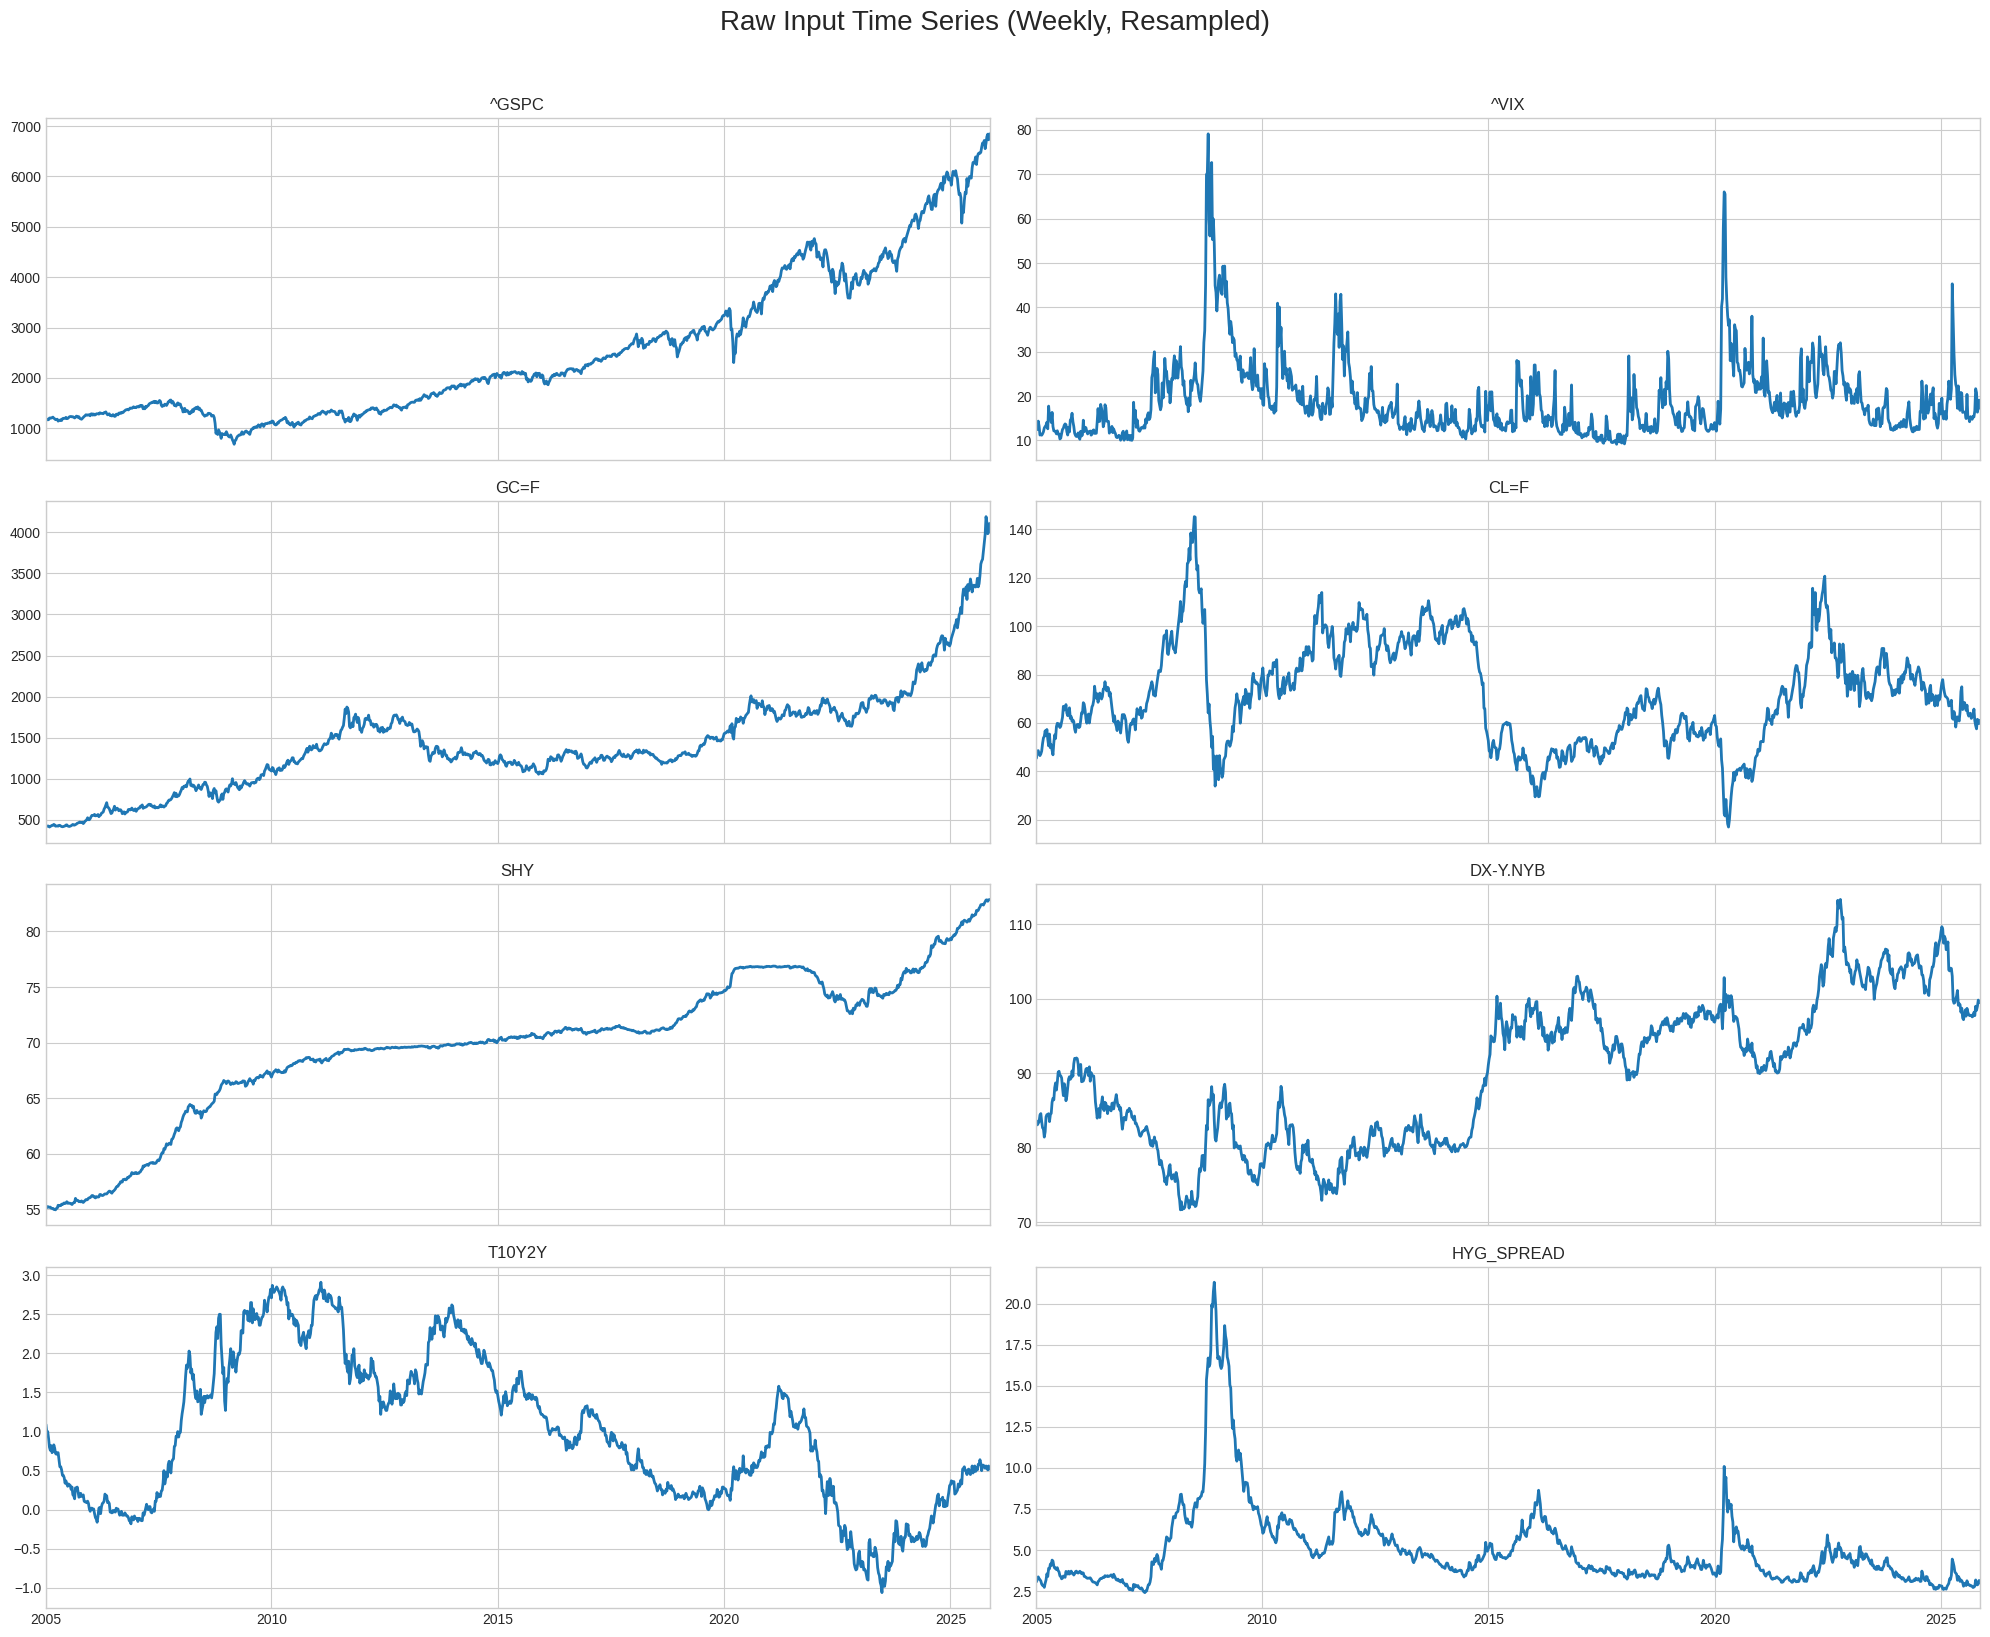

In [ ]:
print("\nVisualizing raw input data...")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 16), sharex=True)
axes_flat = axes.flatten()

for i, col in enumerate(raw_data.columns):
        if i < len(axes_flat):
            raw_data[col].plot(ax=axes_flat[i], title=col, lw=2)
            axes_flat[i].grid(True)

fig.suptitle('Raw Input Time Series (Weekly, Resampled)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


###Phase 2: Feature Engineering & EDA


A `GaussianHMM` assumes features are stationary.\
Price-based assets (like SPX,gold) are non-stationary -> convert to returns (`pct_change()`).\
 We use the Augmented Dickey-Fuller (ADF) test to prove this.
 * `p-value <= 0.05`: Stationary.
 * `p-value > 0.05`: Non-Stationary.

In [ ]:
def run_adf_test(series, name):
    print(f'--- ADF Test for: {name} ---')
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Result: Data is Stationary")
    else:
        print("Result: Data is Non-Stationary")
    print("-" * 30)

In [ ]:
def engineer_features(data):

    features = data.copy()

    # Calculate weekly returns for price-based assets
    features['SPX_ret'] = features['^GSPC'].pct_change()  #percentage change
    features['GOLD_ret'] = features['GC=F'].pct_change()
    features['OIL_ret'] = features['CL=F'].pct_change()
    features['SHY_ret'] = features['SHY'].pct_change()
    features['USD_ret'] = features['DX-Y.NYB'].pct_change()

    #Run Stationarity Tests to Verify ---
    print("\nRunning stationarity tests ...")
    if not features.empty:
        run_adf_test(features['^GSPC'], "S&P (price)")
        run_adf_test(features['SPX_ret'], "S&P (Change)")
        run_adf_test(features['^VIX'], "VIX (Level)")  #it already has p<0.05 so no need to change


    # Define the feature set for the model using the engineered return column names
    feature_columns = ['SPX_ret', '^VIX', 'T10Y2Y', 'HYG_SPREAD', 'OIL_ret', 'GOLD_ret']
    model_features = features[feature_columns].dropna()

    # Separate returns for backtesting
    returns_for_backtest = features[['SPX_ret', 'GOLD_ret', 'OIL_ret']].loc[model_features.index]

    # Standardize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(model_features)
    scaled_features_df = pd.DataFrame(scaled_features, index=model_features.index, columns=model_features.columns)

    return scaled_features_df, returns_for_backtest, model_features



scaled_features, returns, unscaled_features = engineer_features(raw_data)


Running stationarity tests ...
--- ADF Test for: S&P (price) ---
ADF Statistic: 2.3744
p-value: 0.9990
Result: Data is Non-Stationary
------------------------------
--- ADF Test for: S&P (Change) ---
ADF Statistic: -19.9859
p-value: 0.0000
Result: Data is Stationary
------------------------------
--- ADF Test for: VIX (Level) ---
ADF Statistic: -3.9117
p-value: 0.0020
Result: Data is Stationary
------------------------------



Visualizing stationary feature correlation...


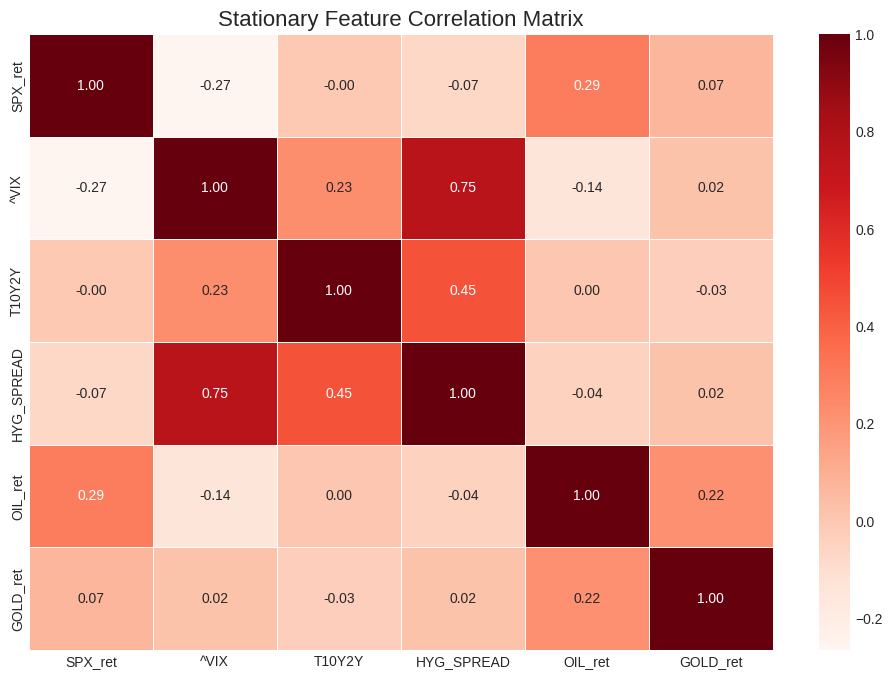

In [ ]:
# Visualize Feature Correlation
print("\nVisualizing stationary feature correlation...")
plt.figure(figsize=(12, 8))
corr_matrix = scaled_features.corr()
sns.heatmap(corr_matrix, annot=True, cmap="Reds", fmt='.2f', linewidths=0.5)
plt.title('Stationary Feature Correlation Matrix', fontsize=16)
plt.show()

###Phase 3: HMM Modeling & Regime Identification

In [ ]:
def train_hmm_model(features, n_regimes=4, n_iter=1000, seed=42):

    print("Phase 3: Training Hidden Markov Model...")

    model = hmm.GaussianHMM(
        n_components=n_regimes,
        covariance_type="full",
        n_iter=n_iter,
        random_state=seed
    )
    model.fit(features)
    regimes = model.predict(features)

    print("HMM training complete.\n")
    return model, regimes


model, regimes = train_hmm_model(scaled_features)


Phase 3: Training Hidden Markov Model...
HMM training complete.



###Phase 4: Regime Interpretation & Visualization

Phase 4: Interpreting and visualizing regimes...
--- Regime Feature Averages ---
         SPX_ret       ^VIX    T10Y2Y  HYG_SPREAD   OIL_ret  GOLD_ret
regime                                                               
0      -0.001317  26.109339  0.892140    6.133619  0.002488  0.003714
1       0.003246  15.245606  0.249771    3.439016  0.003315  0.003497
2       0.003244  15.405242  1.795527    5.001396 -0.000218  0.000025
3      -0.003238  43.795814  2.106977   15.423023 -0.004180  0.002561
-------------------------------



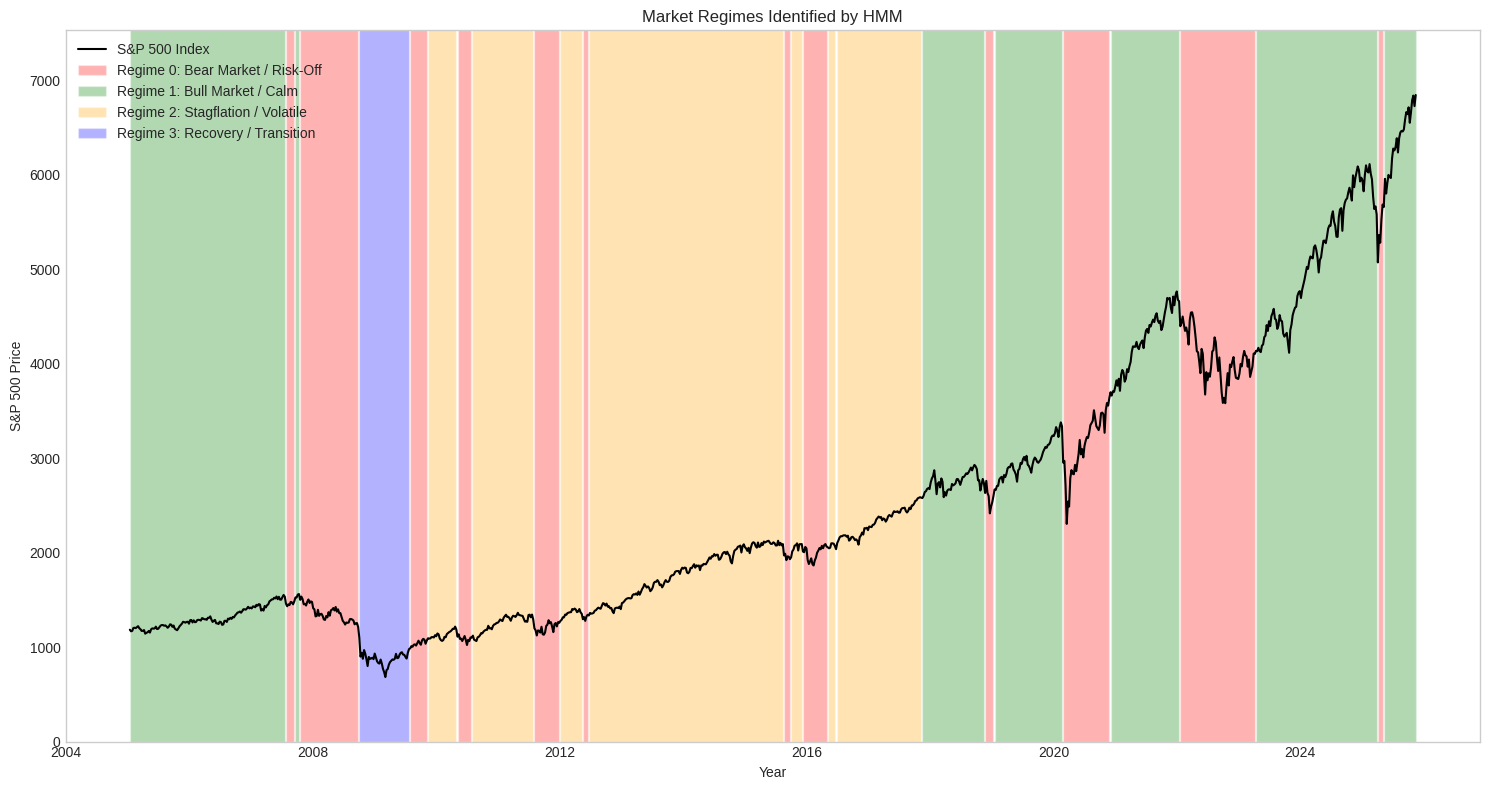

In [ ]:
def interpret_and_plot_regimes(price_data, unscaled_features, regimes):

    print("Phase 4: Interpreting and visualizing regimes...")

    # Align price data with features index
    aligned_price_data = price_data.loc[unscaled_features.index]

    # Analyze regime characteristics
    regime_features = unscaled_features.copy()
    regime_features['regime'] = regimes
    regime_summary = regime_features.groupby('regime').mean()

    print("--- Regime Feature Averages ---")
    print(regime_summary)
    print("-------------------------------\n")

    # Interpret and name regimes based on the summary table
    # This part is subjective and based on financial intuition.
    # E.g., High SPX_ret, low VIX -> Bull Market
    # E.g., Low SPX_ret, high VIX, high HYG_SPREAD -> Bear Market
    regime_names = {
        0: 'Bear Market / Risk-Off',
        1: 'Bull Market / Calm',
        2: 'Stagflation / Volatile',
        3: 'Recovery / Transition'
    }

    # --- Primary Visualization ---
    fig, ax = plt.subplots(figsize=(15, 8))

    # Plot S&P 500 price
    ax.plot(aligned_price_data.index, aligned_price_data['^GSPC'], color='black', linewidth=1.5, label='S&P 500 Index')
    ax.set_ylabel('S&P 500 Price')
    ax.set_title('Market Regimes Identified by HMM')
    ax.grid(False)

    # Shade background based on regime
    colors = ['red', 'green', 'orange', 'blue']
    for i in range(len(regime_names)):
        mask = (regimes == i)
        ax.fill_between(aligned_price_data.index, 0, aligned_price_data['^GSPC'].max() * 1.5,
                        where=mask, facecolor=colors[i], alpha=0.3, label=f'Regime {i}: {regime_names.get(i, "Unknown")}')


    ax.set_ylim(0, aligned_price_data['^GSPC'].max() * 1.1)
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel('Year')
    plt.tight_layout()

    return regime_names


regime_names = interpret_and_plot_regimes(raw_data, unscaled_features, regimes)

### Phase 5: Tactical Asset Allocation (TAA) Backtest

In [ ]:

def calculate_performance_metrics(returns):

    weeks_per_year = 52
    total_weeks = len(returns)

    cumulative_returns = (1 + returns).cumprod()

    # Cumulative Annual Growth Rate (CAGR)
    cagr = (cumulative_returns.iloc[-1])**(weeks_per_year / total_weeks) - 1

    # Annualized Volatility
    volatility = returns.std() * np.sqrt(weeks_per_year)

    # Sharpe Ratio (assuming risk-free rate of 0)
    sharpe_ratio = cagr / volatility if volatility != 0 else 0

    # Maximum Drawdown
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "CAGR": f"{cagr:.2%}",
        "Annualized Volatility": f"{volatility:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}",
        "Maximum Drawdown": f"{max_drawdown:.2%}"
    }


In [ ]:
def run_backtest(returns_df, regimes, allocation_dict):

    print("Phase 5: Running Tactical Asset Allocation Backtest...")

    backtest_data = returns_df.copy()
    backtest_data['regime'] = regimes

    # --- TAA Strategy ---
    taa_returns = []
    for i in range(len(backtest_data)):
        current_regime = backtest_data['regime'].iloc[i]
        weights = allocation_dict.get(current_regime, {'SPX': 1.0})

        weekly_return = 0
        for asset, weight in weights.items():
            asset_ret_col = f"{asset}_ret"
            if asset_ret_col in backtest_data.columns:
                weekly_return += backtest_data[asset_ret_col].iloc[i] * weight
        taa_returns.append(weekly_return)

    backtest_data['taa_returns'] = taa_returns

    # --- NEW BENCHMARK: 100% S&P 500 ---
    backtest_data['benchmark_returns'] = backtest_data['SPX_ret']

    # --- Performance Analysis ---
    taa_metrics = calculate_performance_metrics(backtest_data['taa_returns'])
    benchmark_metrics = calculate_performance_metrics(backtest_data['benchmark_returns'])

    print("\n--- Backtest Performance Metrics ---")
    print("Tactical Asset Allocation (TAA):")
    for metric, value in taa_metrics.items():
        print(f"  - {metric}: {value}")

    # --- UPDATED LABEL ---
    print("\nS&P 500 Benchmark:")
    for metric, value in benchmark_metrics.items():
        print(f"  - {metric}: {value}")

    # Calculate Alpha
    taa_cagr = float(taa_metrics['CAGR'].strip('%'))
    bench_cagr = float(benchmark_metrics['CAGR'].strip('%'))
    alpha = taa_cagr - bench_cagr
    print(f"\n**Strategy Alpha: {alpha:.2f}%**")
    print("------------------------------------\n")

    # Calculate cumulative returns for plotting
    taa_cumulative = (1 + backtest_data['taa_returns']).cumprod()
    benchmark_cumulative = (1 + backtest_data['benchmark_returns']).cumprod()

    # --- Plotting ---
    plt.figure(figsize=(15, 8))
    plt.plot(taa_cumulative, label=f'TAA Strategy (Alpha: {alpha:.2f}%)', color='blue')
    # --- UPDATED LABEL ---
    plt.plot(benchmark_cumulative, label='S&P 500 Benchmark', color='grey', linestyle='--')
    plt.title('Backtest: TAA Strategy vs. S&P 500 Benchmark')
    plt.ylabel('Cumulative Growth of $1')
    plt.xlabel('Year')
    plt.legend()
    plt.yscale('log')
    plt.tight_layout()

    plt.savefig('backtest_performance.png', dpi=300, bbox_inches='tight')
    print("Backtest visualization created.\n")
    return taa_cumulative, benchmark_cumulative

Phase 5: Running Tactical Asset Allocation Backtest...

--- Backtest Performance Metrics ---
Tactical Asset Allocation (TAA):
  - CAGR: 9.71%
  - Annualized Volatility: 16.92%
  - Sharpe Ratio: 0.57
  - Maximum Drawdown: -46.97%

S&P 500 Benchmark:
  - CAGR: 8.74%
  - Annualized Volatility: 17.53%
  - Sharpe Ratio: 0.50
  - Maximum Drawdown: -56.24%

**Strategy Alpha: 0.97%**
------------------------------------

Backtest visualization created.



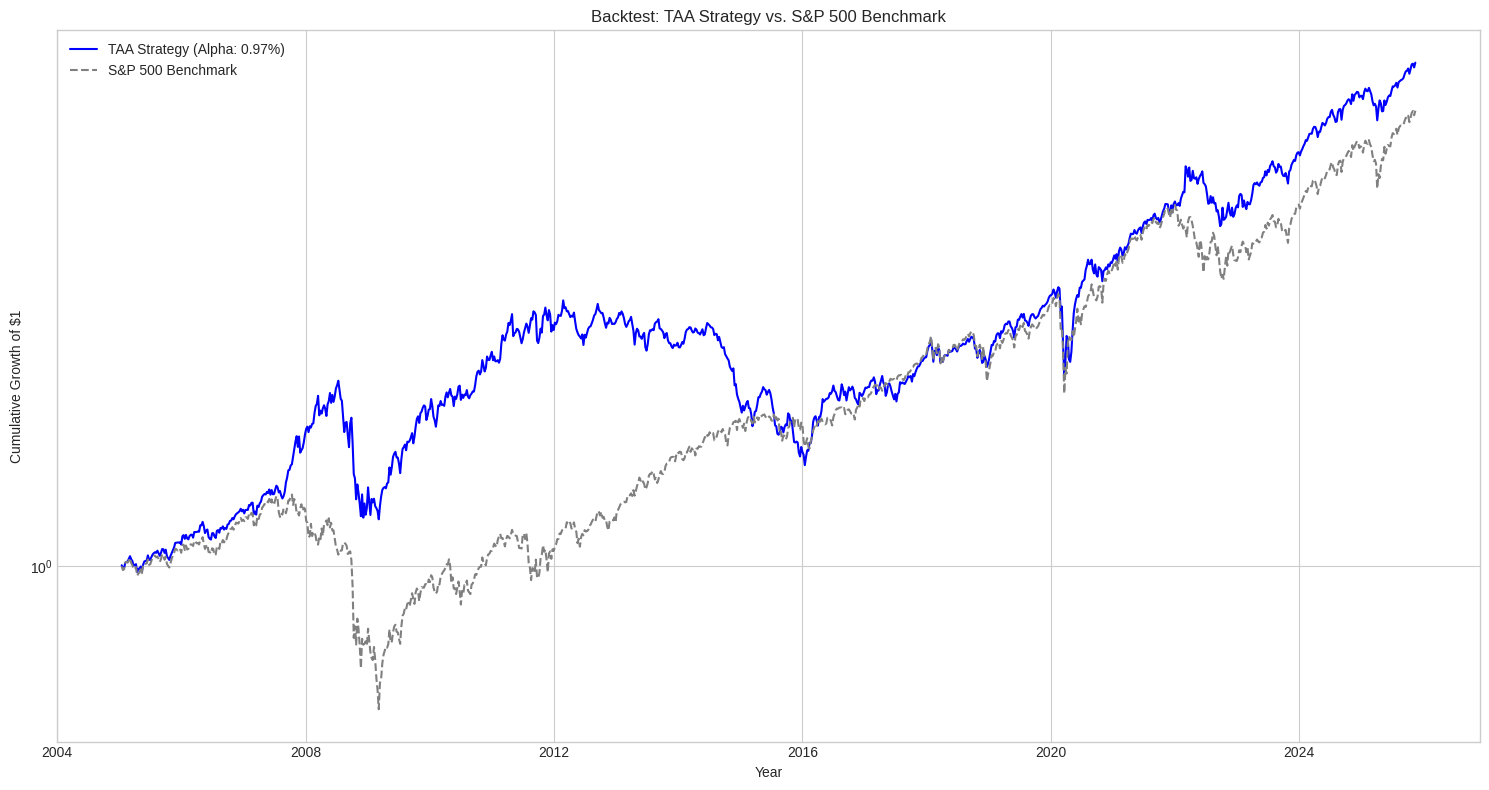

In [ ]:
    REGIME_ASSET_ALLOCATION = {
        # Regime 0: 'Bear Market / Risk-Off' -> Defensive assets like Gold
        0: {'SPX': 0.05, 'GOLD': 0.65, 'OIL': 0.30},
        # Regime 1: 'Bull Market / Calm' -> Pro-growth assets like Equities
        1: {'SPX': 0.85, 'GOLD': 0.10, 'OIL': 0.05},
        # Regime 2: 'Stagflation / Volatile' -> Inflation hedges like Gold and Oil
        2: {'SPX': 0.10, 'GOLD': 0.50, 'OIL': 0.40},
        # Regime 3: 'Recovery / Transition' -> Balanced, leaning towards growth
        3: {'SPX': 0.50, 'GOLD': 0.30, 'OIL': 0.20}
    }

    run_backtest(returns, regimes, REGIME_ASSET_ALLOCATION)

    # Display all generated plots
    plt.show()